# Visualizing Electoral State Voting Power

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
elect_pop_data = pd.read_csv("data/electoral_population_data.csv")
elect_pop_data.head()

,Unnamed: 0,rank,state,state_code,2020_census,percent_of_total,elect_votes_by_percent,new_vote_by_min_pop
0,0,1,California,CA,39538223,0.1193,64.0,69.0
1,1,2,Texas,TX,29145505,0.0879,47.0,51.0
2,2,3,Florida,FL,21538187,0.0650,35.0,37.0
3,3,4,New York,NY,20201249,0.0609,33.0,35.0
4,4,5,Pennsylvania,PA,13002700,0.0392,21.0,23.0


In [3]:
electoral_data = pd.read_csv("data/electoral_data.csv")
electoral_data.head()

,State,[1788],[1792],"[1796, 1800]","[1804, 1808]",[1812],[1816],[1820],"[1824, 1828]",[1832],...,"[1944, 1948]","[1952, 1956]",[1960],"[1964, 1968]","[1972, 1976, 1980]","[1984, 1988]","[1992, 1996, 2000]","[2004, 2008]","[2012, 2016, 2020]","[2024, 2028]"
0,Alabama,0,0,0,0,0,0,3,5,7,...,11,11,11,10,9,9,9,9,9,9
1,Alaska,0,0,0,0,0,0,0,0,0,...,0,0,3,3,3,3,3,3,3,3
2,Arizona,0,0,0,0,0,0,0,0,0,...,4,4,4,5,6,7,8,10,11,11
3,Arkansas,0,0,0,0,0,0,0,0,0,...,9,8,8,6,6,6,6,6,6,6
4,California,0,0,0,0,0,0,0,0,0,...,25,32,32,40,45,47,54,55,55,54


In [4]:
electoral_24 = electoral_data[["State", "[2024, 2028]"]]
electoral_df = pd.merge(elect_pop_data, electoral_24, left_on="state", right_on="State")

# keep one column of state names
electoral_df = electoral_df.drop(columns=["state"])

In [5]:
# reorder columns

# get list of column names for easier copy/paste to create a new list
columns = []

for col in electoral_df.columns:
    columns.append(col)

col_order = ['rank', 'State', 'state_code', '2020_census', 'percent_of_total', '[2024, 2028]', 'elect_votes_by_percent', 'new_vote_by_min_pop',]

electoral_df = electoral_df[col_order]
electoral_df.head()

,rank,State,state_code,2020_census,percent_of_total,"[2024, 2028]",elect_votes_by_percent,new_vote_by_min_pop
0,1,California,CA,39538223,0.1193,54,64.0,69.0
1,2,Texas,TX,29145505,0.0879,40,47.0,51.0
2,3,Florida,FL,21538187,0.0650,30,35.0,37.0
3,4,New York,NY,20201249,0.0609,28,33.0,35.0
4,5,Pennsylvania,PA,13002700,0.0392,19,21.0,23.0


In [6]:
electoral_df = electoral_df.rename(columns={"[2024, 2028]":"electoral_votes"})

In [7]:
fig = px.choropleth(
    electoral_df,
    locations="state_code",
    locationmode="USA-states",
    color="percent_of_total",
    hover_name="State",
    color_continuous_scale="deep",
    scope="usa",
    title="Percentage of U.S. Population",
    hover_data=["percent_of_total"]
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="albers usa"),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

This map shows the population density of each state. Most states fall in the 2-4% range. California, being the most populous, looks black since nearly 12% of the total population resides there.

In [8]:
fig = px.choropleth(
    electoral_df,
    locations="state_code",
    locationmode="USA-states",
    color="electoral_votes",
    hover_name="State",
    color_continuous_scale="deep",
    scope="usa",
    title="Electoral Votes Per State",
    hover_data=["electoral_votes"]
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="albers usa"),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

This map looks very similar to the population map, which would suggest that the current electoral college system aligns and works with the population of each state. Any state, regardless of population, has at least three electoral votes. Now let's look at the voting power of each state with the current system.

In [9]:
# calculate the voting power of each state given the electoral votes and the state population
# first calculate the number of people represented by each electoral vote and add a column with these values
electoral_df["pop_per_elector"] = round(electoral_df["2020_census"] / electoral_df["electoral_votes"], 2)
electoral_df.head()

,rank,State,state_code,2020_census,percent_of_total,electoral_votes,elect_votes_by_percent,new_vote_by_min_pop,pop_per_elector
0,1,California,CA,39538223,0.1193,54,64.0,69.0,732189.31
1,2,Texas,TX,29145505,0.0879,40,47.0,51.0,728637.62
2,3,Florida,FL,21538187,0.0650,30,35.0,37.0,717939.57
3,4,New York,NY,20201249,0.0609,28,33.0,35.0,721473.18
4,5,Pennsylvania,PA,13002700,0.0392,19,21.0,23.0,684352.63


In [10]:
# calculate the number of people who should be represented given the total number of votes
# total electoral votes
total_votes = electoral_df["electoral_votes"].sum()

# total population
total_pop = electoral_df["2020_census"].sum()

# calculate the voting power (total population divided by the total electoral votes
total_pop_elector = round(total_pop / total_votes, 2)

print(f"Each electoral vote should represent {total_pop_elector} people.")

Each electoral vote should represent 618242.5 people.


In [11]:
# calculate the voting power of each state, add column to table

electoral_df["proportional_vote"] = round(total_pop_elector / electoral_df["pop_per_elector"],2)
electoral_df.head()

,rank,State,state_code,2020_census,percent_of_total,electoral_votes,elect_votes_by_percent,new_vote_by_min_pop,pop_per_elector,proportional_vote
0,1,California,CA,39538223,0.1193,54,64.0,69.0,732189.31,0.84
1,2,Texas,TX,29145505,0.0879,40,47.0,51.0,728637.62,0.85
2,3,Florida,FL,21538187,0.0650,30,35.0,37.0,717939.57,0.86
3,4,New York,NY,20201249,0.0609,28,33.0,35.0,721473.18,0.86
4,5,Pennsylvania,PA,13002700,0.0392,19,21.0,23.0,684352.63,0.90


The number of electoral votes has not actually changed since the 1964 election cycle. States have gained or lost votes during each census, but the total number has remained constant for 60+ years. The U.S. population was calculated to be 179,323,175 in the 1960 census. The current population is estimated to be 331,449,281. Source: https://www.census.gov/data/tables/time-series/dec/popchange-data-text.html

## Voting Power by State

In [12]:
fig = px.choropleth(
    electoral_df,
    locations="state_code",
    locationmode="USA-states",
    color="proportional_vote",
    hover_name="State",
    color_continuous_scale="deep",
    scope="usa",
    title="Electoral Voting Power by State"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="albers usa"),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

Note: Washington D.C. is on this map, but you have to zoom in quite a bit to see it.

Now we can see the change in the amount of voting power each state has. Because there are three votes guaranteed to any state, regardless of population, this means that less populous states get more representatives than the population would warrant. Here we see that Wyoming, Vermont, D.C. (zoom in), and Alaska all have a smaller population per elector. This equates to the uneven distribution of voting power and bolsters the votes of those less populated states. Wyoming has a voting power of over 3 times the amount that each elector should have given the population. California, Texas, Florida, and New York all have less voting power; more individuals are represented by their electors.

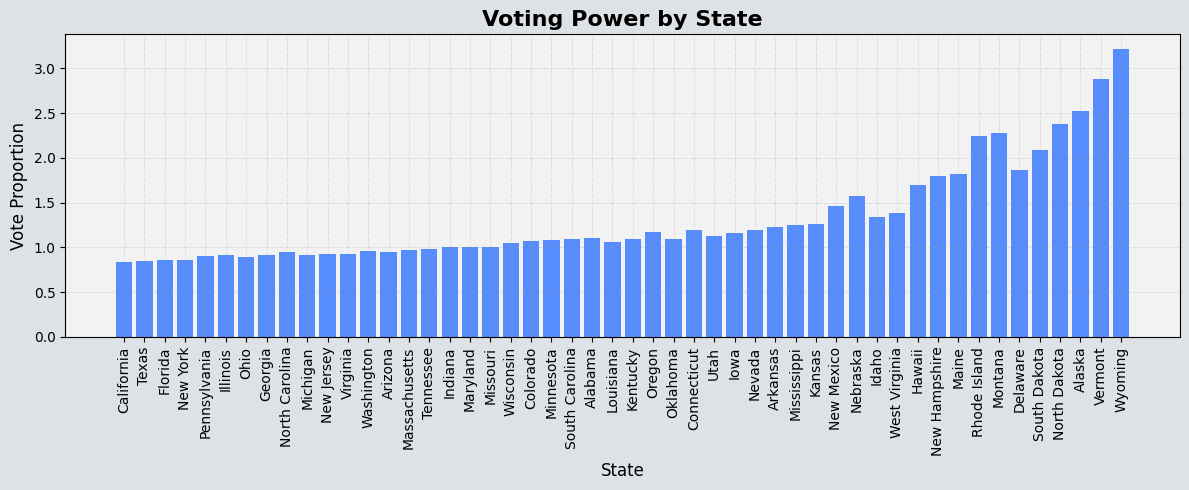

In [13]:
# Visualization of state electoral voting power

# value counts
x = electoral_df["State"]
y = electoral_df["proportional_vote"]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x, y)

ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels(x, rotation=90, ha="center")

ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Vote Proportion", fontsize=12)
ax.set_title("Voting Power by State", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

plt.tight_layout()
plt.show()

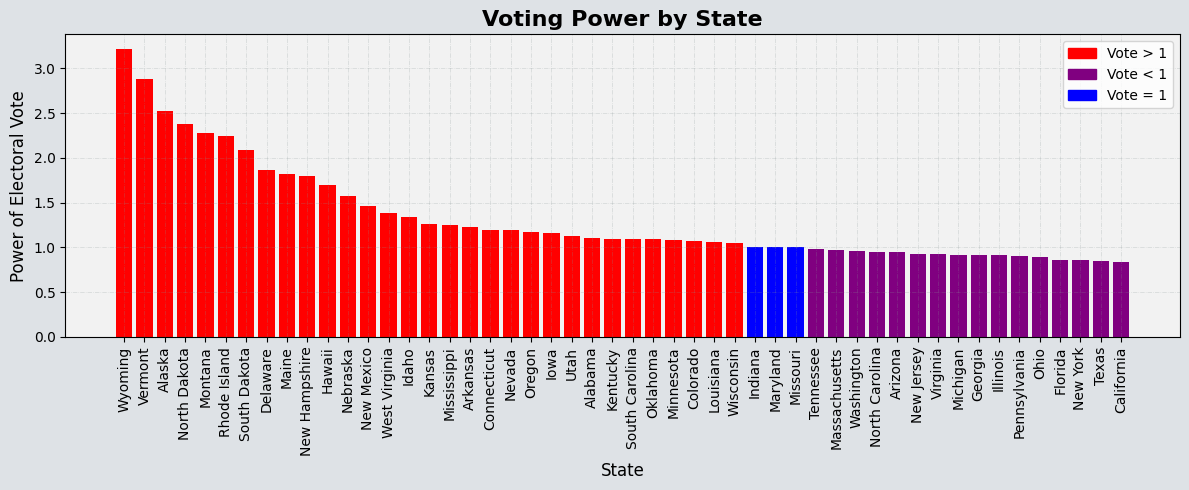

In [14]:
# visualization of voting power by state

# sort values for visually appealing graph
prop_vote_sorted = electoral_df.sort_values(by="proportional_vote", ascending=False)

# value counts
x = prop_vote_sorted["State"]
y = prop_vote_sorted["proportional_vote"]

# color variation to show the skew in voting power
colors = []

for val in y:
    if val < 1:
        colors.append('purple')
    elif val > 1:
        colors.append('red')
    else:
        colors.append('blue')

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("#DEE2E6")
ax.set_facecolor('#F2F2F2')

plt.ticklabel_format(axis='y', style='plain')
plt.bar(x, y, color=colors)

ticks = ax.get_xticks()
ax.set_xticks(ticks)
ax.set_xticklabels(x, rotation=90, ha="center")

ax.set_xlabel("State", fontsize=12)
ax.set_ylabel("Power of Electoral Vote", fontsize=12)
ax.set_title("Voting Power by State", fontsize=16, fontweight="bold")
ax.grid(alpha=0.3, linestyle='-.', color="#889696")

import matplotlib.patches as mpatches

red_patch = mpatches.Patch(color='red', label='Vote > 1')
blue_patch = mpatches.Patch(color='purple', label='Vote < 1')
purple_patch = mpatches.Patch(color='blue', label='Vote = 1')

ax.legend(handles=[red_patch, blue_patch, purple_patch])

plt.tight_layout()
plt.show()

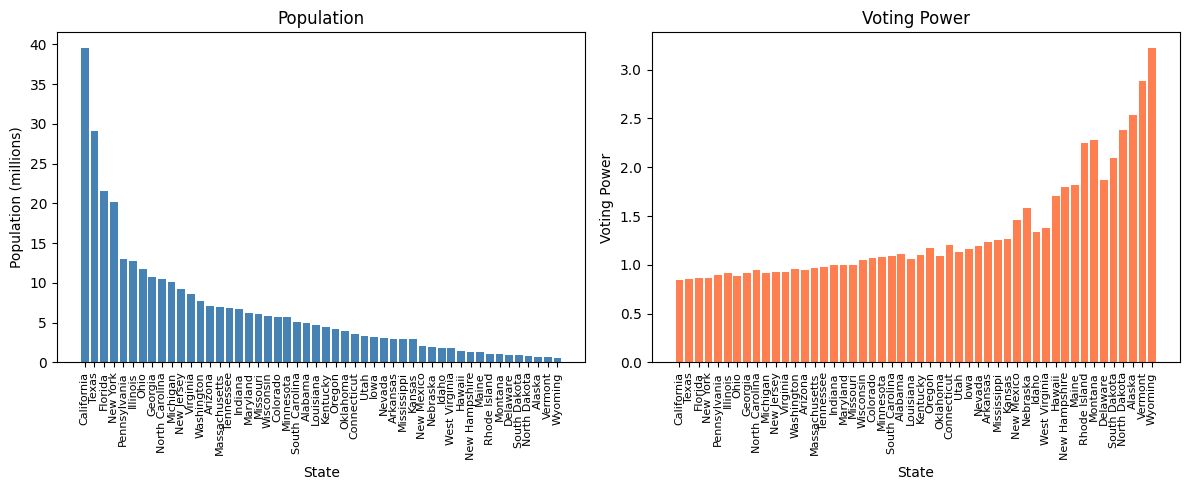

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # sharey=False and sharex=False are the defaults

# Left chart: Population (2020 census)
ax1.bar(electoral_df["State"], electoral_df["2020_census"] / 1000000, color='steelblue')
ax1.set_title('Population')
ax1.set_xlabel('State')
ax1.set_ylabel('Population (millions)')
ax1.tick_params(axis='x', rotation=90, labelsize=8)

# Right chart: Electoral College Voting Power
ax2.bar(electoral_df["State"], electoral_df["proportional_vote"], color='coral')
ax2.set_title('Voting Power')
ax2.set_xlabel('State')
ax2.set_ylabel('Voting Power')
ax2.tick_params(axis='x', rotation=90, labelsize=8)

plt.tight_layout()
plt.show()

Here, side by side is the comparison of the population of each state with the voting power they hold with the electoral college. The order the states, long the x-axis, remain the same, showing the inversion of increased population with lower voting power.